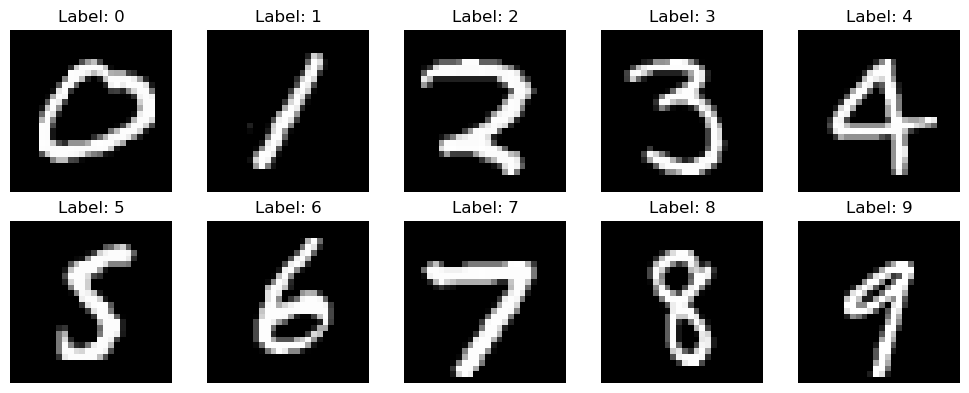

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Load the fixed CSV
df = pd.read_csv("mnist_train.csv")

# Group by class label
grouped = df.groupby("label")

# Prepare empty lists for train and test splits
train_list = []
test_list = []

# Split each class group into 80% train and 20% test
for label, group in grouped:
    train_split, test_split = train_test_split(
        group, 
        test_size=0.2, 
        random_state=42, 
        shuffle=True,
        stratify=None  # We are already splitting by class manually
    )
    train_list.append(train_split)
    test_list.append(test_split)

# Concatenate all class-wise splits
train_df = pd.concat(train_list).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat(test_list).sample(frac=1, random_state=42).reset_index(drop=True)


# One example per class
examples = train_df.groupby("label").first().reset_index()

# Plot
plt.figure(figsize=(10, 4))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    img = examples.loc[i].drop("label").values.astype(np.uint8).reshape(28, 28)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {examples.loc[i, 'label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [2]:
y=df.iloc[:,0].values#.reshape(-1,1)
X=df.iloc[0: ,1:].values
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [3]:
print(y.shape)
print(X.shape)
y=y.astype(int)
data=pd.read_csv("mnist_test.csv")
X_test=data.iloc[0: ,1:].values
Y_test=data.iloc[:,0].values#.reshape(-1,1)

(60000,)
(60000, 784)


0 Training cost 2.4419959518498477 Training accuracy 0.0914 Testing cost 2.31669130595483 Testing accuracy 0.1406
1 Training cost 2.315029430774769 Training accuracy 0.14743333333333333 Testing cost 2.228776891637377 Testing accuracy 0.192
2 Training cost 2.2285863407936928 Training accuracy 0.19795 Testing cost 2.1573456520008234 Testing accuracy 0.2486
3 Training cost 2.158561734866862 Training accuracy 0.254 Testing cost 2.0920947871407916 Testing accuracy 0.3012
4 Training cost 2.0949209934413404 Training accuracy 0.3039833333333333 Testing cost 2.0286400389078523 Testing accuracy 0.3452
5 Training cost 2.033240839568707 Training accuracy 0.34468333333333334 Testing cost 1.964810278176328 Testing accuracy 0.3862
6 Training cost 1.971550590295043 Training accuracy 0.38556666666666667 Testing cost 1.899776343974736 Testing accuracy 0.4335
7 Training cost 1.9088288042652735 Training accuracy 0.42691666666666667 Testing cost 1.8331902338746848 Testing accuracy 0.4809
8 Training cost 1.

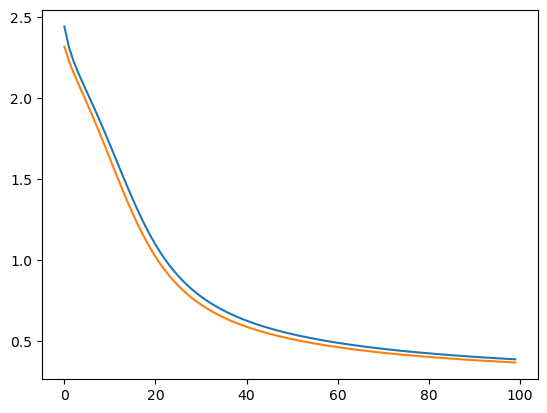

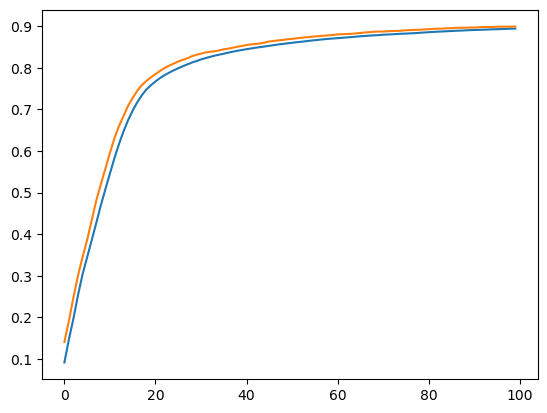

In [4]:
X = X/255 #(X - X.mean(axis=0)) / (X.std(axis=0) + 1e-10)
X_test= X_test/255 #(X_test - X.mean(axis=0)) / (X.std(axis=0) + 1e-10)

#one-hot-encoding
y_onehot= np.eye(10)[y]
y_onehot_test=np.eye(10)[Y_test]

#neuron-architecture
neuron_layers=[128,64,10]
activations = ["relu","relu","softmax"]

w=[]
b=[]
z=[]
m=len(X)
cost_history=[]
accuracy=[]
cost_history_test=[]
accuracy_test=[]

#relu-function
def Relu(z):
    return np.maximum(0,z)

#relu-derivative
def r_derivative(z):
     return np.where(z > 0, 1, 0)
    
#softmax-function
def softmax(z):
    z=z-np.max(z,axis=0,keepdims= True)
    exp_z=np.exp(z)
    return (exp_z/(np.sum(exp_z,axis=0,keepdims=True)) + 1e-10)
    
w.append(np.random.randn(neuron_layers[0],len(X[0])) * np.sqrt(2/len(X[0])))
b.append(np.zeros((neuron_layers[0],1)))

for i in range(1,len(neuron_layers)):
    ww=np.random.randn(neuron_layers[i],neuron_layers[i-1]) * np.sqrt(2/neuron_layers[i-1])
    bb=np.zeros(((neuron_layers[i],1)))
    b.append(bb)
    w.append(ww)
    
#learning-rate
alpha=0.1


for iteration in range(100):
    A=X.T
    z=[]
    AA=[]
    dldw=[]
    dldb=[]

    #forward-propagation
    for i in range(len(neuron_layers)):
        #print(w[i].shape, A.shape, b[i].shape)    
        zz=np.dot(w[i],A) + b[i]
        #print(zz.shape)
        if activations[i]=="softmax":
            A=softmax(zz)
        if activations[i]=="relu":
            A=Relu(zz)
        z.append(zz)
        AA.append(A)
           
    cost = -np.sum(y_onehot * np.log(A.T + 1e-10)) / m
    cost_history.append(cost)

    y_pred=np.argmax(A.T,axis=1)
    a=np.sum(y==y_pred)/y.shape[0]
    
    accuracy.append(a)

    #back-propagation
    for i in range(len(neuron_layers)-1,-1,-1): 
       if i == len(neuron_layers)-1: 
          d=AA[i]-y_onehot.T 
       else:
           d=w[i+1].T @ d * r_derivative(z[i]) 
             
       if i==0:
          dldw.append((d @ X)/m)
          dldb.append(np.sum(d,axis=1,keepdims=True)/m)
       else:
          dldw.append((d @ AA[i-1].T)/m )
          dldb.append(np.sum(d,axis=1,keepdims=True)/m)
    
    dldw = dldw[::-1]
    dldb = dldb[::-1]

    for i in range(len(w)):
        w[i] = w[i] - alpha * dldw[i]
        b[i] = b[i] - alpha * dldb[i]
        
    A=X_test.T
    
    for i in range(len(neuron_layers)):  
        zz=np.dot(w[i],A) + b[i]
        if activations[i]=="softmax":
            A=softmax(zz)
        if activations[i]=="relu":
            A=Relu(zz)
        

    
    cost_test = -np.sum(y_onehot_test * np.log(A.T + 1e-10)) / len(X_test)
    
    cost_history_test.append(cost_test)
    

    y_pred=np.argmax(A.T,axis=1)
    a_test=np.sum(Y_test==y_pred)/Y_test.shape[0]
    accuracy_test.append(a_test)h

    print(iteration, "Training cost",cost,"Training accuracy",a,"Testing cost",cost_test,"Testing accuracy",a_test)

        
plt.plot(cost_history)
plt.plot(cost_history_test)
plt.show()

plt.plot(accuracy)
plt.plot(accuracy_test)
plt.show()